# Etna Cause–Trigger Analysis

This notebook applies the Cause–Trigger algorithm to the Etna 2008 case. 

The full dataset is used only as the constructed data product; the algorithm is applied to a fixed case-study interval \(I\) around the event. Within this interval, the split into \(I_1\) and \(I_2\) is selected automatically from the effect variable.

## 1. Imports, paths, and case-study interval

In [1]:
from pathlib import Path
import sys
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data" / "etna"

for path in [SRC_DIR, NOTEBOOK_DIR]:
    if str(path) not in sys.path:
        sys.path.append(str(path))

from cause_trigger_etna import *

ETNA_PATH = DATA_DIR / "etna_final.csv"
EVENT_TIME = pd.Timestamp("2008-05-12 06:28:00", tz="UTC")

In [2]:
X_full = load_model_frame(ETNA_PATH)

CASE_START = EVENT_TIME - pd.Timedelta(days=3)
CASE_END = EVENT_TIME + pd.Timedelta(hours=36)

X = X_full.loc[CASE_START:CASE_END].copy()

display(pd.DataFrame([model_overview(X, EFFECT)]))

,n_rows,n_variables,start,end,inferred_frequency,effect,effect_min,effect_median,effect_mean,effect_max,effect_abs_mean,effect_iqr,effect_n_unique
0,108,8,2008-05-09 07:00:00+00:00,2008-05-13 18:00:00+00:00,h,effect_seismic_scaled,-0.648533,-0.475611,0.247879,2.011561,0.906165,2.436063,108


## 2. Reference lag selection

VAR-AIC and VAR-BIC are used only as automatic reference lags. The final interpretation is based on lag stability over lags 1–12 rather than on a single information-criterion choice.

In [3]:
MAX_LAGS = 12

reference_parameters = pd.DataFrame([
    select_parameters(
        X,
        EFFECT,
        max_lags=MAX_LAGS,
        criterion="aic",
        fallback_lag=1,
        fallback_distribution="gaussian",
    ),
    select_parameters(
        X,
        EFFECT,
        max_lags=MAX_LAGS,
        criterion="bic",
        fallback_lag=1,
        fallback_distribution="gaussian",
    ),
])

display(reference_parameters)

aic_row = reference_parameters.loc[
    reference_parameters["lag_method"] == "VAR-AIC"
].iloc[0]

selected_lag = int(aic_row["selected_lag"])
selected_distribution = aic_row["selected_distribution"]

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


,effect,selected_lag,selected_distribution,lag_method,max_lags,fallback_lag,fallback_distribution
0,effect_seismic_scaled,1,gaussian,VAR-AIC,12,1,gaussian
1,effect_seismic_scaled,1,gaussian,VAR-BIC,12,1,gaussian


## 3. Main configuration and automatic split

The main configuration uses the original split rule inside the fixed case-study interval. The event time is shown only for interpretation; it is not used by the split algorithm.

Rows in X: 108
Required minimum: 96


,effect,split_index,split_time,I1_length,I2_length,abs_mean_I1,abs_mean_I2,abs_mean_difference,event_time,distance_to_event,boundary_split,split_end_index,split_end_time,split_score,signed_mean_I1,signed_mean_I2
0,effect_seismic_scaled,None,None,None,None,None,None,None,2008-05-12 06:28:00+00:00,None,None,None,None,None,None,None


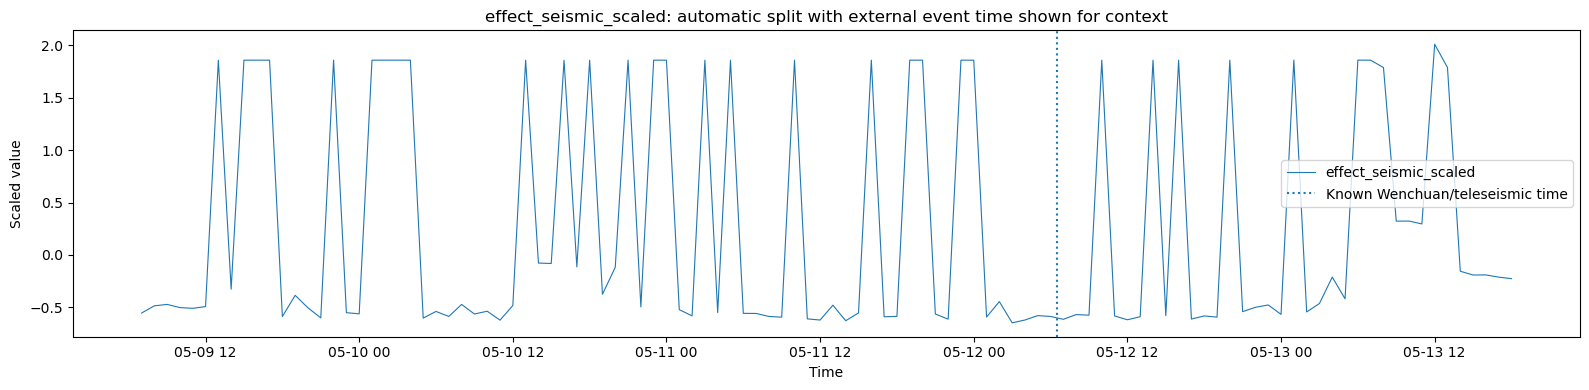

In [ ]:
workflow = EtnaWorkflowConfig(
    effect=EFFECT,
    event_time=EVENT_TIME,
    alpha=0.05,
    selected_lag=selected_lag,
    max_lags=MAX_LAGS,
    min_I1_length=48,
    min_I2_length=48,
    distribution=selected_distribution,
    parameter_source="automatic_reference",
)

print("Rows in X:", len(X))
print("Required minimum:", workflow.min_I1_length + workflow.min_I2_length)

assert len(X) >= workflow.min_I1_length + workflow.min_I2_length

main_split = split_diagnostics(
    X,
    EFFECT,
    event_time=EVENT_TIME,
    min_I1_length=workflow.min_I1_length,
    min_I2_length=workflow.min_I2_length,
)

display(pd.DataFrame([main_split]))

plot_effect_with_split(
    X,
    EFFECT,
    main_split,
    event_time=workflow.event_time,
)

## 4. Reference-lag backend comparison

This run reports the behavior at the VAR-AIC reference lag. It is not treated as the final lag choice unless it is supported by the lag-stability grid.

In [5]:
results, comparison, diagnostics = run_suite(
    X,
    workflow,
    lag=workflow.selected_lag,
    distribution=workflow.distribution,
    cond_ind_test="parcorr",
)

display(compact_comparison(comparison))
display(compact_diagnostics(diagnostics))

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom


,run,backend,configured_lags,configured_distribution,split_timestamp,I1_length,I2_length,B2,trigger_candidates,accepted_triggers,causes,pairs,stop_reason
0,hmml_backend_beta,hmml,1,gaussian,None,None,None,[],[],[],[CO2_3_scaled],[],No valid I1/I2 split found.
1,pcmci_ridge,pcmci,1,gaussian,None,None,None,[],[],[],[],[],No valid I1/I2 split found.
2,pcmci_plus_ridge,pcmci_plus,1,gaussian,None,None,None,[],[],[],[],[],No valid I1/I2 split found.


""


## 5. HMML lag-stability grid

The HMML backend is the baseline. A cause-trigger pair is considered stable if it appears across at least two adjacent lags in the 1–12 grid.

In [6]:
hmml_sensitivity = run_sensitivity_grid(
    X,
    workflow,
    run_specs=({"run": "hmml_backend_beta", "backend": "hmml"},),
    lags=range(1, workflow.max_lags + 1),
    distributions=(workflow.distribution,),
)

hmml_accepted = accepted_sensitivity_rows(hmml_sensitivity)
hmml_stability = summarise_lag_stability(
    hmml_sensitivity,
    backend="hmml",
    reference_lag=workflow.selected_lag,
    min_adjacent=2,
)

display(hmml_accepted)
display(hmml_stability)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) *

""


""


In [7]:
if not hmml_stability.empty and hmml_stability["stable"].any():
    representative_lag = int(
        hmml_stability.loc[hmml_stability["stable"], "recommended_lag"].iloc[0]
    )
    representative_pair = hmml_stability.loc[hmml_stability["stable"], "pair"].iloc[0]
else:
    representative_lag = workflow.selected_lag
    representative_pair = None

summary_choice = pd.DataFrame([{
    "reference_lag_VAR_AIC": workflow.selected_lag,
    "representative_lag": representative_lag,
    "representative_pair": representative_pair,
}])

display(summary_choice)

,reference_lag_VAR_AIC,representative_lag,representative_pair
0,1,1,None


## 6. PCMCI lagged-link robustness

PCMCI is used as a stricter supplementary backend. This section uses only lagged PCMCI links and does not include contemporaneous trigger candidates.

In [8]:
pcmci_sensitivity = run_sensitivity_grid(
    X,
    workflow,
    run_specs=({"run": "pcmci_ridge", "backend": "pcmci"},),
    lags=range(1, workflow.max_lags + 1),
    distributions=(workflow.distribution,),
    cond_ind_test="parcorr",
    use_contemporaneous_triggers=False,
)

display(compact_sensitivity(pcmci_sensitivity))
display(accepted_sensitivity_rows(pcmci_sensitivity))

,run,backend,lag,distribution,split_timestamp,I1_length,I2_length,B_2,trigger_candidates,T_candidates_lagged,T_candidates_contemporaneous,accepted_triggers,causes,pairs,min_p_value,max_rss_reduction_ratio,n_contemporaneous_links,error
0,pcmci_ridge,pcmci,1,gaussian,None,None,None,[],[],None,None,[],[],[],None,None,0,None
1,pcmci_ridge,pcmci,2,gaussian,None,None,None,[],[],None,None,[],[],[],None,None,0,None
2,pcmci_ridge,pcmci,3,gaussian,None,None,None,[],[],None,None,[],[],[],None,None,0,None
3,pcmci_ridge,pcmci,4,gaussian,None,None,None,[],[],None,None,[],[],[],None,None,0,None
4,pcmci_ridge,pcmci,5,gaussian,None,None,None,[],[],None,None,[],[],[],None,None,0,None
5,pcmci_ridge,pcmci,6,gaussian,None,None,None,[],[],None,None,[],[],[],None,None,0,None
6,pcmci_ridge,pcmci,7,gaussian,None,None,None,[],[],None,None,[],[],[],None,None,0,None
7,pcmci_ridge,pcmci,8,gaussian,None,None,None,[],[],None,None,[],[],[],None,None,0,None
8,pcmci_ridge,pcmci,9,gaussian,None,None,None,[],[],None,None,[],[],[],None,None,0,None
9,pcmci_ridge,pcmci,10,gaussian,None,None,None,[],[],None,None,[],[],[],None,None,0,None


""


## 7. PCMCI+ contemporaneous-trigger extension

PCMCI+ is used as a separate supplementary extension because it can estimate contemporaneous \(tau=0\) links. In this section, significant contemporaneous source-target links are allowed as immediate trigger candidates. They are not added to \(B_2\), and \(V\) is still constructed only from lagged \(B_2\) parents.

In [9]:
pcmci_plus_tau0_sensitivity = run_sensitivity_grid(
    X,
    workflow,
    run_specs=({"run": "pcmci_plus_tau0_ridge", "backend": "pcmci_plus"},),
    lags=range(1, workflow.max_lags + 1),
    distributions=(workflow.distribution,),
    cond_ind_test="parcorr",
    use_contemporaneous_triggers=True,
)

display(compact_sensitivity(pcmci_plus_tau0_sensitivity))
display(accepted_sensitivity_rows(pcmci_plus_tau0_sensitivity))

,run,backend,lag,distribution,split_timestamp,I1_length,I2_length,B_2,trigger_candidates,T_candidates_lagged,T_candidates_contemporaneous,accepted_triggers,causes,pairs,min_p_value,max_rss_reduction_ratio,n_contemporaneous_links,error
0,pcmci_plus_tau0_ridge,pcmci_plus,1,gaussian,None,None,None,[],[],None,None,[],[],[],None,None,0,None
1,pcmci_plus_tau0_ridge,pcmci_plus,2,gaussian,None,None,None,[],[],None,None,[],[],[],None,None,0,None
2,pcmci_plus_tau0_ridge,pcmci_plus,3,gaussian,None,None,None,[],[],None,None,[],[],[],None,None,0,None
3,pcmci_plus_tau0_ridge,pcmci_plus,4,gaussian,None,None,None,[],[],None,None,[],[],[],None,None,0,None
4,pcmci_plus_tau0_ridge,pcmci_plus,5,gaussian,None,None,None,[],[],None,None,[],[],[],None,None,0,None
5,pcmci_plus_tau0_ridge,pcmci_plus,6,gaussian,None,None,None,[],[],None,None,[],[],[],None,None,0,None
6,pcmci_plus_tau0_ridge,pcmci_plus,7,gaussian,None,None,None,[],[],None,None,[],[],[],None,None,0,None
7,pcmci_plus_tau0_ridge,pcmci_plus,8,gaussian,None,None,None,[],[],None,None,[],[],[],None,None,0,None
8,pcmci_plus_tau0_ridge,pcmci_plus,9,gaussian,None,None,None,[],[],None,None,[],[],[],None,None,0,None
9,pcmci_plus_tau0_ridge,pcmci_plus,10,gaussian,None,None,None,[],[],None,None,[],[],[],None,None,0,None


""
